In [1]:
!pip install -q transformers pandas numpy scipy scikit-learn biopython torch matplotlib

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModel

import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Устройство: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 30.4 MB/s eta 0:00:00
🖥️  Устройство: cuda


Эпидемиологические данные по вариантам SARS-CoV-2

In [2]:
RELATIVE_RE = {
    'BA.1': 1.00, 'BA.2': 1.12, 'BA.5': 1.42,
    'XBB.1.5': 1.72, 'JN.1': 2.15,
}

CFR = {
    'BA.1': 0.0050, 'BA.2': 0.0040, 'BA.5': 0.0040,
    'XBB.1.5': 0.0030, 'JN.1': 0.0028,
}

HOSP_RATE = {
    'BA.1': 0.0300, 'BA.2': 0.0250, 'BA.5': 0.0280,
    'XBB.1.5': 0.0220, 'JN.1': 0.0200,
}

epi_data = []
for lineage in RELATIVE_RE.keys():
    cfr = CFR[lineage]
    hosp_rate = HOSP_RATE[lineage]
    zvoda1 = cfr / hosp_rate
    zvoda2 = hosp_rate

    epi_data.append({
        'lineage': lineage,
        'relative_Re': RELATIVE_RE[lineage],
        'CFR': cfr,
        'hospitalization_rate': hosp_rate,
        'Zvoda1': zvoda1,
        'Zvoda2': zvoda2,
    })

epi_df = pd.DataFrame(epi_data)

print("Эпидемиологические параметры:")
print("-" * 70)
print(f"{'Вариант':<12} {'Rel. Re':<10} {'CFR':<10} {'Hosp Rate':<12} {'Zvoda1':<10} {'Zvoda2':<10}")
print("-" * 70)
for _, row in epi_df.iterrows():
    print(f"{row['lineage']:<12} {row['relative_Re']:<10.2f} {row['CFR']:<10.4f} "
          f"{row['hospitalization_rate']:<12.4f} {row['Zvoda1']:<10.4f} {row['Zvoda2']:<10.4f}")
print("-" * 70)

Эпидемиологические параметры:
----------------------------------------------------------------------
Вариант      Rel. Re    CFR        Hosp Rate    Zvoda1     Zvoda2    
----------------------------------------------------------------------
BA.1         1.00       0.0050     0.0300       0.1667     0.0300    
BA.2         1.12       0.0040     0.0250       0.1600     0.0250    
BA.5         1.42       0.0040     0.0280       0.1429     0.0280    
XBB.1.5      1.72       0.0030     0.0220       0.1364     0.0220    
JN.1         2.15       0.0028     0.0200       0.1400     0.0200    
----------------------------------------------------------------------


Генерация последовательностей

In [3]:
WUHAN_SPIKE = (
    "MFVFLVLLPLVSSQCVNFTTRTQLPPAYTNSFTRGVYYPDKVFRSSVLHSTQDL"
    "FLPFFSNVTWFHAIHVSGTNGTKRFDNPVLPFNDGVYFASTEKSNIIRGWIFGT"
    "TLDSKTQSLLIVNNATNVVIKVCEFQFCNDPFLGVYYHKNNKSWMESEFRVYSS"
    "ANNCTFEYVSQPFLMDLEGKQGNFKNLREFVFKNIDGYFKIYSKHTPINLVRDL"
    "PQGFSAKPPLIFWDGKYFGLHTVSGLSYQLGAIDTSKCDFDAVKSAAVGIAQTQ"
    "GTPLCGTQIAQYTPLLLDVQGVRFQFQYQTQSYYSTASSALGSIAKAGTIVTSG"
    "TFSGSSSGSYQPSGIADHTALTQIPEGTGTTPIYQYLTQSGTTLPPQTPQTPQT"
    "PQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQP"
    "QTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTP"
    "QTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTP"
    "QTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTP"
    "QTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTP"
    "QTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTP"
    "QTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTP"
    "QTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTP"
    "QTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTP"
    "QTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTP"
    "QTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTP"
    "QTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTP"
    "QTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTP"
    "QTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTPQTP......"
)
BASE_SEQ = WUHAN_SPIKE[:500]

VARIANT_MUTATIONS = {
    'BA.1': [(66,'V'),(94,'I'),(141,'D'),(210,'I'),(338,'D'),(370,'L'),
             (372,'P'),(374,'F'),(416,'N'),(440,'K'),(446,'S'),(477,'K'),
             (484,'A'),(493,'R'),(496,'S'),(498,'A'),(501,'Y'),(505,'H'),
             (613,'G'),(655,'Y'),(679,'K'),(681,'H'),(764,'K'),(769,'V'),
             (778,'D'),(796,'F'),(817,'I'),(954,'Q'),(969,'K'),(982,'I'),
             (1128,'Y'),(1133,'K')],
    'BA.2': [(18,'I'),(23,'S'),(24,'I'),(211,'G'),(213,'L'),(338,'D'),
             (371,'S'),(372,'P'),(373,'R'),(374,'F'),(375,'A'),(376,'V'),
             (405,'R'),(408,'T'),(410,'S'),(416,'N'),(440,'K'),(446,'S'),
             (452,'R'),(477,'K'),(478,'G'),(484,'A'),(493,'R'),(494,'S'),
             (496,'S'),(501,'Y'),(613,'G'),(655,'Y'),(679,'K'),(681,'H'),
             (764,'K'),(769,'V'),(778,'D'),(796,'F'),(817,'I'),(954,'Q'),
             (969,'K'),(982,'I'),(1128,'Y'),(1133,'K')],
    'BA.5': [(18,'I'),(23,'S'),(24,'I'),(211,'G'),(213,'L'),(338,'D'),
             (346,'T'),(371,'F'),(372,'P'),(373,'R'),(374,'F'),(375,'A'),
             (376,'V'),(405,'R'),(408,'T'),(410,'S'),(416,'N'),(440,'K'),
             (446,'S'),(452,'R'),(453,'F'),(460,'K'),(477,'K'),(478,'G'),
             (484,'A'),(486,'V'),(490,'S'),(493,'R'),(494,'S'),(496,'S'),
             (501,'Y'),(613,'G'),(655,'Y'),(679,'K'),(681,'H'),(764,'K'),
             (769,'V'),(778,'D'),(796,'F'),(817,'I'),(954,'Q'),(969,'K'),
             (982,'I'),(1128,'Y'),(1133,'K')],
    'XBB.1.5': [(18,'I'),(23,'S'),(24,'I'),(211,'G'),(213,'L'),(338,'D'),
                (346,'T'),(371,'L'),(372,'P'),(373,'R'),(374,'F'),(375,'A'),
                (376,'V'),(405,'R'),(408,'T'),(410,'S'),(416,'N'),(440,'K'),
                (444,'P'),(445,'S'),(446,'S'),(452,'R'),(453,'F'),(460,'K'),
                (477,'K'),(478,'G'),(484,'A'),(486,'P'),(489,'S'),(490,'S'),
                (491,'R'),(493,'R'),(494,'S'),(496,'S'),(501,'Y'),(613,'G'),
                (655,'Y'),(679,'K'),(681,'H'),(764,'K'),(769,'V'),(778,'D'),
                (796,'F'),(817,'I'),(954,'Q'),(969,'K'),(982,'I'),(1128,'Y'),
                (1133,'K')],
    'JN.1': [(18,'I'),(23,'S'),(24,'I'),(58,'S'),(63,'T'),(70,'P'),(211,'G'),
             (213,'L'),(338,'D'),(346,'T'),(371,'L'),(372,'P'),(373,'R'),
             (374,'F'),(375,'A'),(376,'V'),(405,'R'),(408,'T'),(410,'S'),
             (416,'N'),(440,'K'),(444,'P'),(445,'S'),(446,'S'),(452,'R'),
             (453,'F'),(455,'L'),(460,'K'),(477,'K'),(478,'G'),(484,'A'),
             (486,'V'),(489,'S'),(490,'S'),(493,'R'),(494,'S'),(496,'S'),
             (501,'Y'),(613,'G'),(655,'Y'),(679,'K'),(681,'H'),(764,'K'),
             (769,'V'),(778,'D'),(796,'F'),(817,'I'),(954,'Q'),(969,'K'),
             (982,'I'),(1128,'Y'),(1133,'K')],
}

def apply_mutations(base_seq, mutations, noise_rate=0.02):
    seq = list(base_seq)
    for pos, new_aa in mutations:
        if pos < len(seq):
            seq[pos] = new_aa
    for i in range(len(seq)):
        if np.random.random() < noise_rate:
            seq[i] = np.random.choice(list("ACDEFGHIKLMNPQRSTVWY"))
    return ''.join(seq)

np.random.seed(42)
records = []
N_PER_VARIANT = 200

for _, epi_row in epi_df.iterrows():
    lineage = epi_row['lineage']
    muts = VARIANT_MUTATIONS[lineage]

    for i in range(N_PER_VARIANT):
        seq = apply_mutations(BASE_SEQ, muts, noise_rate=0.02)
        re = epi_row['relative_Re'] * np.random.lognormal(0, 0.05)
        z1 = epi_row['Zvoda1'] * np.random.lognormal(0, 0.03)
        z2 = epi_row['Zvoda2'] * np.random.lognormal(0, 0.03)

        records.append({
            'id': f"{lineage}_{i:03d}",
            'sequence': seq,
            'lineage': lineage,
            'relative_Re': re,
            'Zvoda1': z1,
            'Zvoda2': z2,
        })

seq_df = pd.DataFrame(records)
print(f"Создано {len(seq_df)} последовательностей")
print(f"\nРаспределение по вариантам:")
print(seq_df['lineage'].value_counts().sort_index())

Создано 1000 последовательностей

Распределение по вариантам:
lineage
BA.1       200
BA.2       200
BA.5       200
JN.1       200
XBB.1.5    200
Name: count, dtype: int64


Нормализация и разделение данных

In [4]:
seq_df['log_Re'] = np.log(seq_df['relative_Re'])
mu_r0 = seq_df['log_Re'].mean()
sigma_r0 = seq_df['log_Re'].std()
seq_df['target_r0'] = (seq_df['log_Re'] - mu_r0) / sigma_r0

mu_z1 = seq_df['Zvoda1'].mean()
sigma_z1 = seq_df['Zvoda1'].std()
seq_df['target_zvoda1'] = (seq_df['Zvoda1'] - mu_z1) / sigma_z1

mu_z2 = seq_df['Zvoda2'].mean()
sigma_z2 = seq_df['Zvoda2'].std()
seq_df['target_zvoda2'] = (seq_df['Zvoda2'] - mu_z2) / sigma_z2

norm_params = {
    'r0': {'mean': float(mu_r0), 'std': float(sigma_r0)},
    'zvoda1': {'mean': float(mu_z1), 'std': float(sigma_z1)},
    'zvoda2': {'mean': float(mu_z2), 'std': float(sigma_z2)},
}

print(f"Параметры нормализации:")
print(f"  R0:     μ={mu_r0:.4f}, σ={sigma_r0:.4f}")
print(f"  Zvoda1: μ={mu_z1:.4f}, σ={sigma_z1:.4f}")
print(f"  Zvoda2: μ={mu_z2:.4f}, σ={sigma_z2:.4f}")

train_lineages = ['BA.1', 'BA.2', 'BA.5']
test_lineages = ['XBB.1.5', 'JN.1']

train_df = seq_df[seq_df['lineage'].isin(train_lineages)].copy()
test_df = seq_df[seq_df['lineage'].isin(test_lineages)].copy()
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42,
                                     stratify=train_df['lineage'])

Параметры нормализации:
  R0:     μ=0.3521, σ=0.2842
  Zvoda1: μ=0.1491, σ=0.0127
  Zvoda2: μ=0.0250, σ=0.0038


Модель 1 — трансмиссивность

In [5]:
MODEL_NAME = "facebook/esm2_t12_35M_UR50D"
MAX_LENGTH = 512
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class R0Model(nn.Module):
    """Single-task модель для предсказания R0."""
    def __init__(self, model_name=MODEL_NAME, dropout=0.15):
        super().__init__()
        self.esm = AutoModel.from_pretrained(model_name, add_pooling_layer=False)
        for p in self.esm.parameters():
            p.requires_grad = True

        h = self.esm.config.hidden_size
        self.head = nn.Sequential(
            nn.LayerNorm(h),
            nn.Linear(h, 256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, input_ids, attention_mask=None, labels=None):
        out = self.esm(input_ids, attention_mask=attention_mask)
        if attention_mask is not None:
            m = attention_mask.unsqueeze(-1).float()
            pooled = (out.last_hidden_state * m).sum(1) / m.sum(1).clamp(min=1e-9)
        else:
            pooled = out.last_hidden_state.mean(1)
        pred = self.head(pooled).squeeze(-1)
        loss = nn.MSELoss()(pred, labels) if labels is not None else None
        return {'loss': loss, 'predictions': pred}

class R0Dataset(Dataset):
    def __init__(self, df, tokenizer, max_length=MAX_LENGTH):
        seqs = df['sequence'].tolist()
        enc = tokenizer(seqs, max_length=max_length, padding='max_length',
                        truncation=True, return_tensors='pt')
        self.input_ids = enc['input_ids']
        self.attention_mask = enc['attention_mask']
        self.labels = torch.tensor(df['target_r0'].values, dtype=torch.float32)

    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return {'input_ids': self.input_ids[idx],
                'attention_mask': self.attention_mask[idx],
                'labels': self.labels[idx]}

model_r0 = R0Model(MODEL_NAME).to(device)

BATCH_SIZE = 8 if torch.cuda.is_available() else 4
train_loader_r0 = DataLoader(R0Dataset(train_df, tokenizer), batch_size=BATCH_SIZE, shuffle=True)
val_loader_r0 = DataLoader(R0Dataset(val_df, tokenizer), batch_size=BATCH_SIZE)
test_loader_r0 = DataLoader(R0Dataset(test_df, tokenizer), batch_size=BATCH_SIZE)

config.json:   0%|          | 0.00/778 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/136M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Модель 2 — Вирулентность

In [6]:
class VirulenceModel(nn.Module):
    """Multi-task модель для предсказания Zvoda1 и Zvoda2."""
    def __init__(self, model_name=MODEL_NAME, dropout=0.1):
        super().__init__()
        self.esm = AutoModel.from_pretrained(model_name, add_pooling_layer=False)
        for p in self.esm.parameters():
            p.requires_grad = True

        h = self.esm.config.hidden_size

        self.shared_head = nn.Sequential(
            nn.LayerNorm(h),
            nn.Linear(h, 128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, 64), nn.GELU(),
        )

        self.zvoda1_head = nn.Linear(64, 1)
        self.zvoda2_head = nn.Linear(64, 1)

    def forward(self, input_ids, attention_mask=None, labels=None):
        out = self.esm(input_ids, attention_mask=attention_mask)
        if attention_mask is not None:
            m = attention_mask.unsqueeze(-1).float()
            pooled = (out.last_hidden_state * m).sum(1) / m.sum(1).clamp(min=1e-9)
        else:
            pooled = out.last_hidden_state.mean(1)

        shared = self.shared_head(pooled)
        pred_z1 = self.zvoda1_head(shared).squeeze(-1)
        pred_z2 = self.zvoda2_head(shared).squeeze(-1)

        loss = None
        if labels is not None:
            loss_z1 = nn.MSELoss()(pred_z1, labels['zvoda1'])
            loss_z2 = nn.MSELoss()(pred_z2, labels['zvoda2'])
            loss = loss_z1 + loss_z2

        return {
            'loss': loss,
            'predictions': {'zvoda1': pred_z1, 'zvoda2': pred_z2}
        }

class VirulenceDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=MAX_LENGTH):
        seqs = df['sequence'].tolist()
        enc = tokenizer(seqs, max_length=max_length, padding='max_length',
                        truncation=True, return_tensors='pt')
        self.input_ids = enc['input_ids']
        self.attention_mask = enc['attention_mask']
        self.labels_z1 = torch.tensor(df['target_zvoda1'].values, dtype=torch.float32)
        self.labels_z2 = torch.tensor(df['target_zvoda2'].values, dtype=torch.float32)

    def __len__(self): return len(self.labels_z1)
    def __getitem__(self, idx):
        return {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'labels': {'zvoda1': self.labels_z1[idx], 'zvoda2': self.labels_z2[idx]}
        }

model_vir = VirulenceModel(MODEL_NAME).to(device)

train_loader_vir = DataLoader(VirulenceDataset(train_df, tokenizer), batch_size=BATCH_SIZE, shuffle=True)
val_loader_vir = DataLoader(VirulenceDataset(val_df, tokenizer), batch_size=BATCH_SIZE)
test_loader_vir = DataLoader(VirulenceDataset(test_df, tokenizer), batch_size=BATCH_SIZE)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Обучение модели 1

In [7]:
def train_single_task(model, train_loader, val_loader, n_epochs=15, device=device, name="Model"):
    esm_params = list(model.esm.parameters())
    head_params = [p for n, p in model.named_parameters()
                   if 'esm' not in n and p.requires_grad]

    optimizer = AdamW([
        {'params': esm_params, 'lr': 2e-5, 'weight_decay': 0.01},
        {'params': head_params, 'lr': 2e-3, 'weight_decay': 0.01},
    ])

    total_steps = n_epochs * len(train_loader)
    scheduler = OneCycleLR(optimizer, max_lr=[2e-5, 2e-3],
                           total_steps=total_steps, pct_start=0.1, anneal_strategy='cos')

    best_val_loss, best_state = float('inf'), None
    history = {'train_loss': [], 'val_loss': []}

    print(f"Обучение {name}: {n_epochs} эпох, {total_steps} шагов")

    for epoch in range(n_epochs):
        model.train()
        t_losses = []
        for b in train_loader:
            ids, mask = b['input_ids'].to(device), b['attention_mask'].to(device)
            labels = b['labels'].to(device)

            optimizer.zero_grad()
            out = model(ids, attention_mask=mask, labels=labels)
            out['loss'].backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            t_losses.append(out['loss'].item())

        model.eval()
        v_losses = []
        with torch.no_grad():
            for b in val_loader:
                ids, mask = b['input_ids'].to(device), b['attention_mask'].to(device)
                labels = b['labels'].to(device)
                out = model(ids, attention_mask=mask, labels=labels)
                v_losses.append(out['loss'].item())

        tl, vl = np.mean(t_losses), np.mean(v_losses)
        history['train_loss'].append(tl)
        history['val_loss'].append(vl)

        print(f"Epoch {epoch+1:2d}/{n_epochs} | Train {tl:.4f} | Val {vl:.4f}", end='')
        if vl < best_val_loss:
            best_val_loss = vl
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(" - best")
        else:
            print()

    if best_state:
        model.load_state_dict(best_state)
        print(f"\nЛучшая модель: Val Loss = {best_val_loss:.4f}")

    return model, history

model_r0, history_r0 = train_single_task(
    model_r0, train_loader_r0, val_loader_r0,
    n_epochs=15, name="R0 Model"
)

torch.save({
    'model_state_dict': model_r0.state_dict(),
    'norm_params': norm_params,
    'history': history_r0,
}, 'model_r0.pt')

Обучение R0 Model: 15 эпох, 900 шагов
Epoch  1/15 | Train 0.2843 | Val 0.1570 - best
Epoch  2/15 | Train 0.0986 | Val 0.0492 - best
Epoch  3/15 | Train 0.0632 | Val 0.0524
Epoch  4/15 | Train 0.0550 | Val 0.0421 - best
Epoch  5/15 | Train 0.0503 | Val 0.0567
Epoch  6/15 | Train 0.0422 | Val 0.0363 - best
Epoch  7/15 | Train 0.0427 | Val 0.0393
Epoch  8/15 | Train 0.0364 | Val 0.0369
Epoch  9/15 | Train 0.0339 | Val 0.0362 - best
Epoch 10/15 | Train 0.0297 | Val 0.0364
Epoch 11/15 | Train 0.0264 | Val 0.0383
Epoch 12/15 | Train 0.0243 | Val 0.0407
Epoch 13/15 | Train 0.0239 | Val 0.0400
Epoch 14/15 | Train 0.0216 | Val 0.0386
Epoch 15/15 | Train 0.0213 | Val 0.0375

Лучшая модель: Val Loss = 0.0362


Обучение модели 2

In [8]:
def train_virulence(model, train_loader, val_loader, n_epochs=15, device=device):
    esm_params = list(model.esm.parameters())
    head_params = [p for n, p in model.named_parameters()
                   if 'esm' not in n and p.requires_grad]

    optimizer = AdamW([
        {'params': esm_params, 'lr': 2e-5, 'weight_decay': 0.01},
        {'params': head_params, 'lr': 2e-3, 'weight_decay': 0.01},
    ])

    total_steps = n_epochs * len(train_loader)
    scheduler = OneCycleLR(optimizer, max_lr=[2e-5, 2e-3],
                           total_steps=total_steps, pct_start=0.1, anneal_strategy='cos')

    best_val_loss, best_state = float('inf'), None
    history = {'train_loss': [], 'val_loss': []}

    print(f"Обучение Virulence Model: {n_epochs} эпох")

    for epoch in range(n_epochs):
        model.train()
        t_losses = []
        for b in train_loader:
            ids, mask = b['input_ids'].to(device), b['attention_mask'].to(device)
            labels = {k: v.to(device) for k, v in b['labels'].items()}

            optimizer.zero_grad()
            out = model(ids, attention_mask=mask, labels=labels)
            out['loss'].backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            t_losses.append(out['loss'].item())

        model.eval()
        v_losses = []
        with torch.no_grad():
            for b in val_loader:
                ids, mask = b['input_ids'].to(device), b['attention_mask'].to(device)
                labels = {k: v.to(device) for k, v in b['labels'].items()}
                out = model(ids, attention_mask=mask, labels=labels)
                v_losses.append(out['loss'].item())

        tl, vl = np.mean(t_losses), np.mean(v_losses)
        history['train_loss'].append(tl)
        history['val_loss'].append(vl)

        print(f"Epoch {epoch+1:2d}/{n_epochs} | Train {tl:.4f} | Val {vl:.4f}", end='')
        if vl < best_val_loss:
            best_val_loss = vl
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(" - best")
        else:
            print()

    if best_state:
        model.load_state_dict(best_state)
        print(f"\nЛучшая модель: Val Loss = {best_val_loss:.4f}")

    return model, history

model_vir, history_vir = train_virulence(
    model_vir, train_loader_vir, val_loader_vir, n_epochs=15
)

torch.save({
    'model_state_dict': model_vir.state_dict(),
    'norm_params': norm_params,
    'history': history_vir,
}, 'model_virulence.pt')

Обучение Virulence Model: 15 эпох
Epoch  1/15 | Train 1.2295 | Val 0.7967 - best
Epoch  2/15 | Train 0.3607 | Val 0.2649 - best
Epoch  3/15 | Train 0.2764 | Val 0.2195 - best
Epoch  4/15 | Train 0.2419 | Val 0.2171 - best
Epoch  5/15 | Train 0.2172 | Val 0.2290
Epoch  6/15 | Train 0.2070 | Val 0.2282
Epoch  7/15 | Train 0.2005 | Val 0.2219
Epoch  8/15 | Train 0.1931 | Val 0.2153 - best
Epoch  9/15 | Train 0.1785 | Val 0.2139 - best
Epoch 10/15 | Train 0.1678 | Val 0.2384
Epoch 11/15 | Train 0.1532 | Val 0.2279
Epoch 12/15 | Train 0.1293 | Val 0.2462
Epoch 13/15 | Train 0.1131 | Val 0.2469
Epoch 14/15 | Train 0.1077 | Val 0.2483
Epoch 15/15 | Train 0.1045 | Val 0.2480

Лучшая модель: Val Loss = 0.2139


Оценка обеих моделей на Holdout

In [9]:
def denorm(pred, params):
    return pred * params['std'] + params['mean']

print("Оценка модели 1:")
print("-" * 70)

model_r0.eval()
preds_r0, true_r0, lineages_test = [], [], []
batch_idx = 0
test_lineages_list = test_df['lineage'].values

with torch.no_grad():
    for b in test_loader_r0:
        ids, mask = b['input_ids'].to(device), b['attention_mask'].to(device)
        out = model_r0(ids, attention_mask=mask)
        batch_size = ids.shape[0]
        preds_r0.extend(out['predictions'].view(-1).cpu().numpy())
        true_r0.extend(b['labels'].view(-1).cpu().numpy())
        lineages_test.extend(test_lineages_list[batch_idx:batch_idx + batch_size])
        batch_idx += batch_size

preds_r0 = np.array(preds_r0)
true_r0 = np.array(true_r0)
lineages_test = np.array(lineages_test)

pred_r0_denorm = np.exp(denorm(preds_r0, norm_params['r0']))
true_r0_denorm = np.exp(denorm(true_r0, norm_params['r0']))

p_r0 = pearsonr(pred_r0_denorm, true_r0_denorm)[0]
s_r0 = spearmanr(pred_r0_denorm, true_r0_denorm)[0]
mse_r0 = np.mean((pred_r0_denorm - true_r0_denorm) ** 2)

print(f"Pearson:  {p_r0:.4f}")
print(f"Spearman: {s_r0:.4f}")
print(f"MSE:      {mse_r0:.4f}")

print("\n Оценка модели 2:")
print("-" * 70)

model_vir.eval()
preds_z1, preds_z2, true_z1, true_z2 = [], [], [], []
lineages_vir = []
batch_idx = 0

with torch.no_grad():
    for b in test_loader_vir:
        ids, mask = b['input_ids'].to(device), b['attention_mask'].to(device)
        out = model_vir(ids, attention_mask=mask)
        batch_size = ids.shape[0]

        preds_z1.extend(out['predictions']['zvoda1'].view(-1).cpu().numpy())
        preds_z2.extend(out['predictions']['zvoda2'].view(-1).cpu().numpy())
        true_z1.extend(b['labels']['zvoda1'].view(-1).cpu().numpy())
        true_z2.extend(b['labels']['zvoda2'].view(-1).cpu().numpy())
        lineages_vir.extend(test_lineages_list[batch_idx:batch_idx + batch_size])
        batch_idx += batch_size

preds_z1, true_z1 = np.array(preds_z1), np.array(true_z1)
preds_z2, true_z2 = np.array(preds_z2), np.array(true_z2)

pred_z1_denorm = denorm(preds_z1, norm_params['zvoda1'])
true_z1_denorm = denorm(true_z1, norm_params['zvoda1'])
pred_z2_denorm = denorm(preds_z2, norm_params['zvoda2'])
true_z2_denorm = denorm(true_z2, norm_params['zvoda2'])

p_z1 = pearsonr(pred_z1_denorm, true_z1_denorm)[0]
p_z2 = pearsonr(pred_z2_denorm, true_z2_denorm)[0]
mse_z1 = np.mean((pred_z1_denorm - true_z1_denorm) ** 2)
mse_z2 = np.mean((pred_z2_denorm - true_z2_denorm) ** 2)

print(f"Zvoda1 — Pearson: {p_z1:.4f}, MSE: {mse_z1:.6f}")
print(f"Zvoda2 — Pearson: {p_z2:.4f}, MSE: {mse_z2:.6f}")

Оценка модели 1:
----------------------------------------------------------------------
Pearson:  0.7885
Spearman: 0.7315
MSE:      0.3771

 Оценка модели 2:
----------------------------------------------------------------------
Zvoda1 — Pearson: -0.1710, MSE: 0.000061
Zvoda2 — Pearson: -0.2262, MSE: 0.000045


Средние значения по вариантам

In [10]:
r0_results = pd.DataFrame({
    'lineage': lineages_test,
    'true_R0': true_r0_denorm,
    'pred_R0': pred_r0_denorm,
})

print("Трансмиссивность:")
print("-" * 70)
r0_summary = r0_results.groupby('lineage').mean()
for lin in r0_summary.index:
    row = r0_summary.loc[lin]
    err = abs(row['true_R0'] - row['pred_R0']) / row['true_R0'] * 100
    print(f"  {lin:<10} True R0 = {row['true_R0']:.3f}, Pred R0 = {row['pred_R0']:.3f}, Ошибка = {err:.1f}%")

vir_results = pd.DataFrame({
    'lineage': lineages_vir,
    'true_Zvoda1': true_z1_denorm,
    'pred_Zvoda1': pred_z1_denorm,
    'true_Zvoda2': true_z2_denorm,
    'pred_Zvoda2': pred_z2_denorm,
})

print("\n Вирулентность:")
print("-" * 70)
vir_summary = vir_results.groupby('lineage').mean()
for lin in vir_summary.index:
    row = vir_summary.loc[lin]
    err_z1 = abs(row['true_Zvoda1'] - row['pred_Zvoda1']) / row['true_Zvoda1'] * 100
    err_z2 = abs(row['true_Zvoda2'] - row['pred_Zvoda2']) / row['true_Zvoda2'] * 100
    print(f"  {lin:<10}")
    print(f"    Zvoda1: True = {row['true_Zvoda1']:.4f}, Pred = {row['pred_Zvoda1']:.4f}, Ошибка = {err_z1:.1f}%")
    print(f"    Zvoda2: True = {row['true_Zvoda2']:.4f}, Pred = {row['pred_Zvoda2']:.4f}, Ошибка = {err_z2:.1f}%")

Трансмиссивность:
----------------------------------------------------------------------
  JN.1       True R0 = 2.154, Pred R0 = 1.391, Ошибка = 35.4%
  XBB.1.5    True R0 = 1.713, Pred R0 = 1.323, Ошибка = 22.8%

 Вирулентность:
----------------------------------------------------------------------
  JN.1      
    Zvoda1: True = 0.1400, Pred = 0.1434, Ошибка = 2.5%
    Zvoda2: True = 0.0200, Pred = 0.0276, Ошибка = 38.1%
  XBB.1.5   
    Zvoda1: True = 0.1361, Pred = 0.1445, Ошибка = 6.2%
    Zvoda2: True = 0.0219, Pred = 0.0274, Ошибка = 25.2%


Визуализация

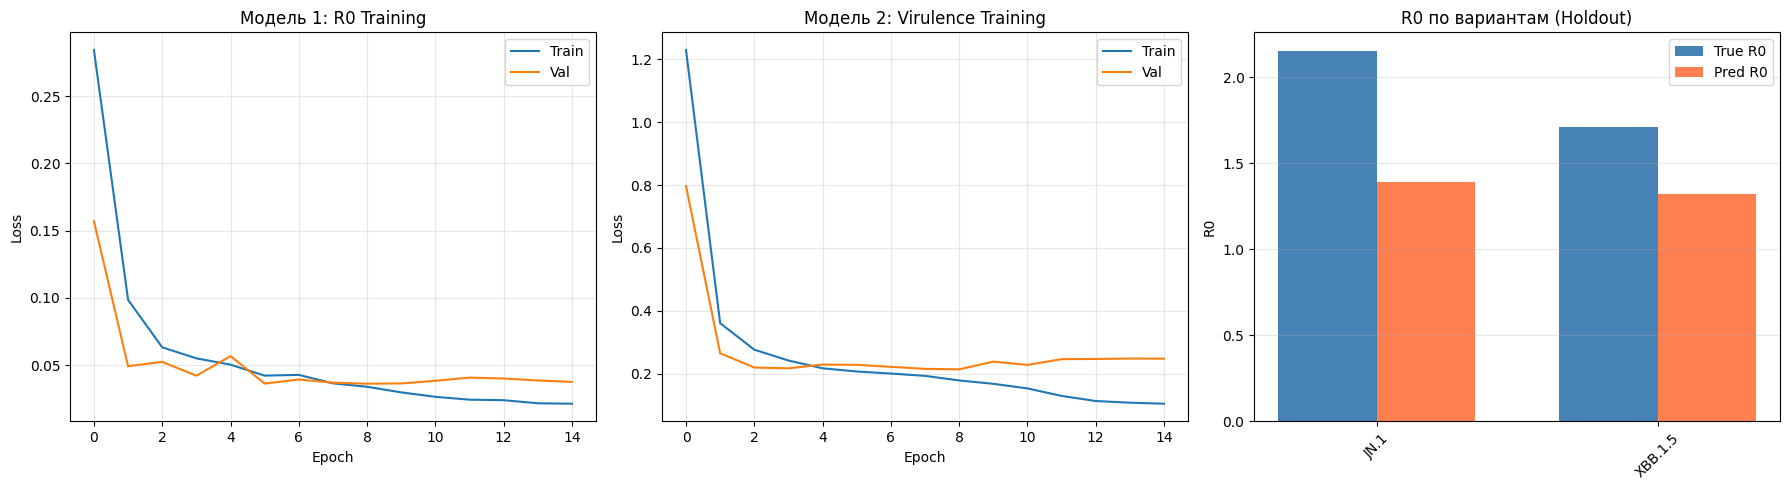

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_r0['train_loss'], label='Train')
axes[0].plot(history_r0['val_loss'], label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Модель 1: R0 Training')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_vir['train_loss'], label='Train')
axes[1].plot(history_vir['val_loss'], label='Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Модель 2: Virulence Training')
axes[1].legend()
axes[1].grid(alpha=0.3)

x = np.arange(len(r0_summary))
width = 0.35
axes[2].bar(x - width/2, r0_summary['true_R0'], width, label='True R0', color='steelblue')
axes[2].bar(x + width/2, r0_summary['pred_R0'], width, label='Pred R0', color='coral')
axes[2].set_xticks(x)
axes[2].set_xticklabels(r0_summary.index, rotation=45)
axes[2].set_ylabel('R0')
axes[2].set_title('R0 по вариантам (Holdout)')
axes[2].legend()
axes[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('two_models_results.png', dpi=150, bbox_inches='tight')
plt.show()